# Интерпретация

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных
data = pd.read_csv("data_unreg.csv")

# Признаки
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


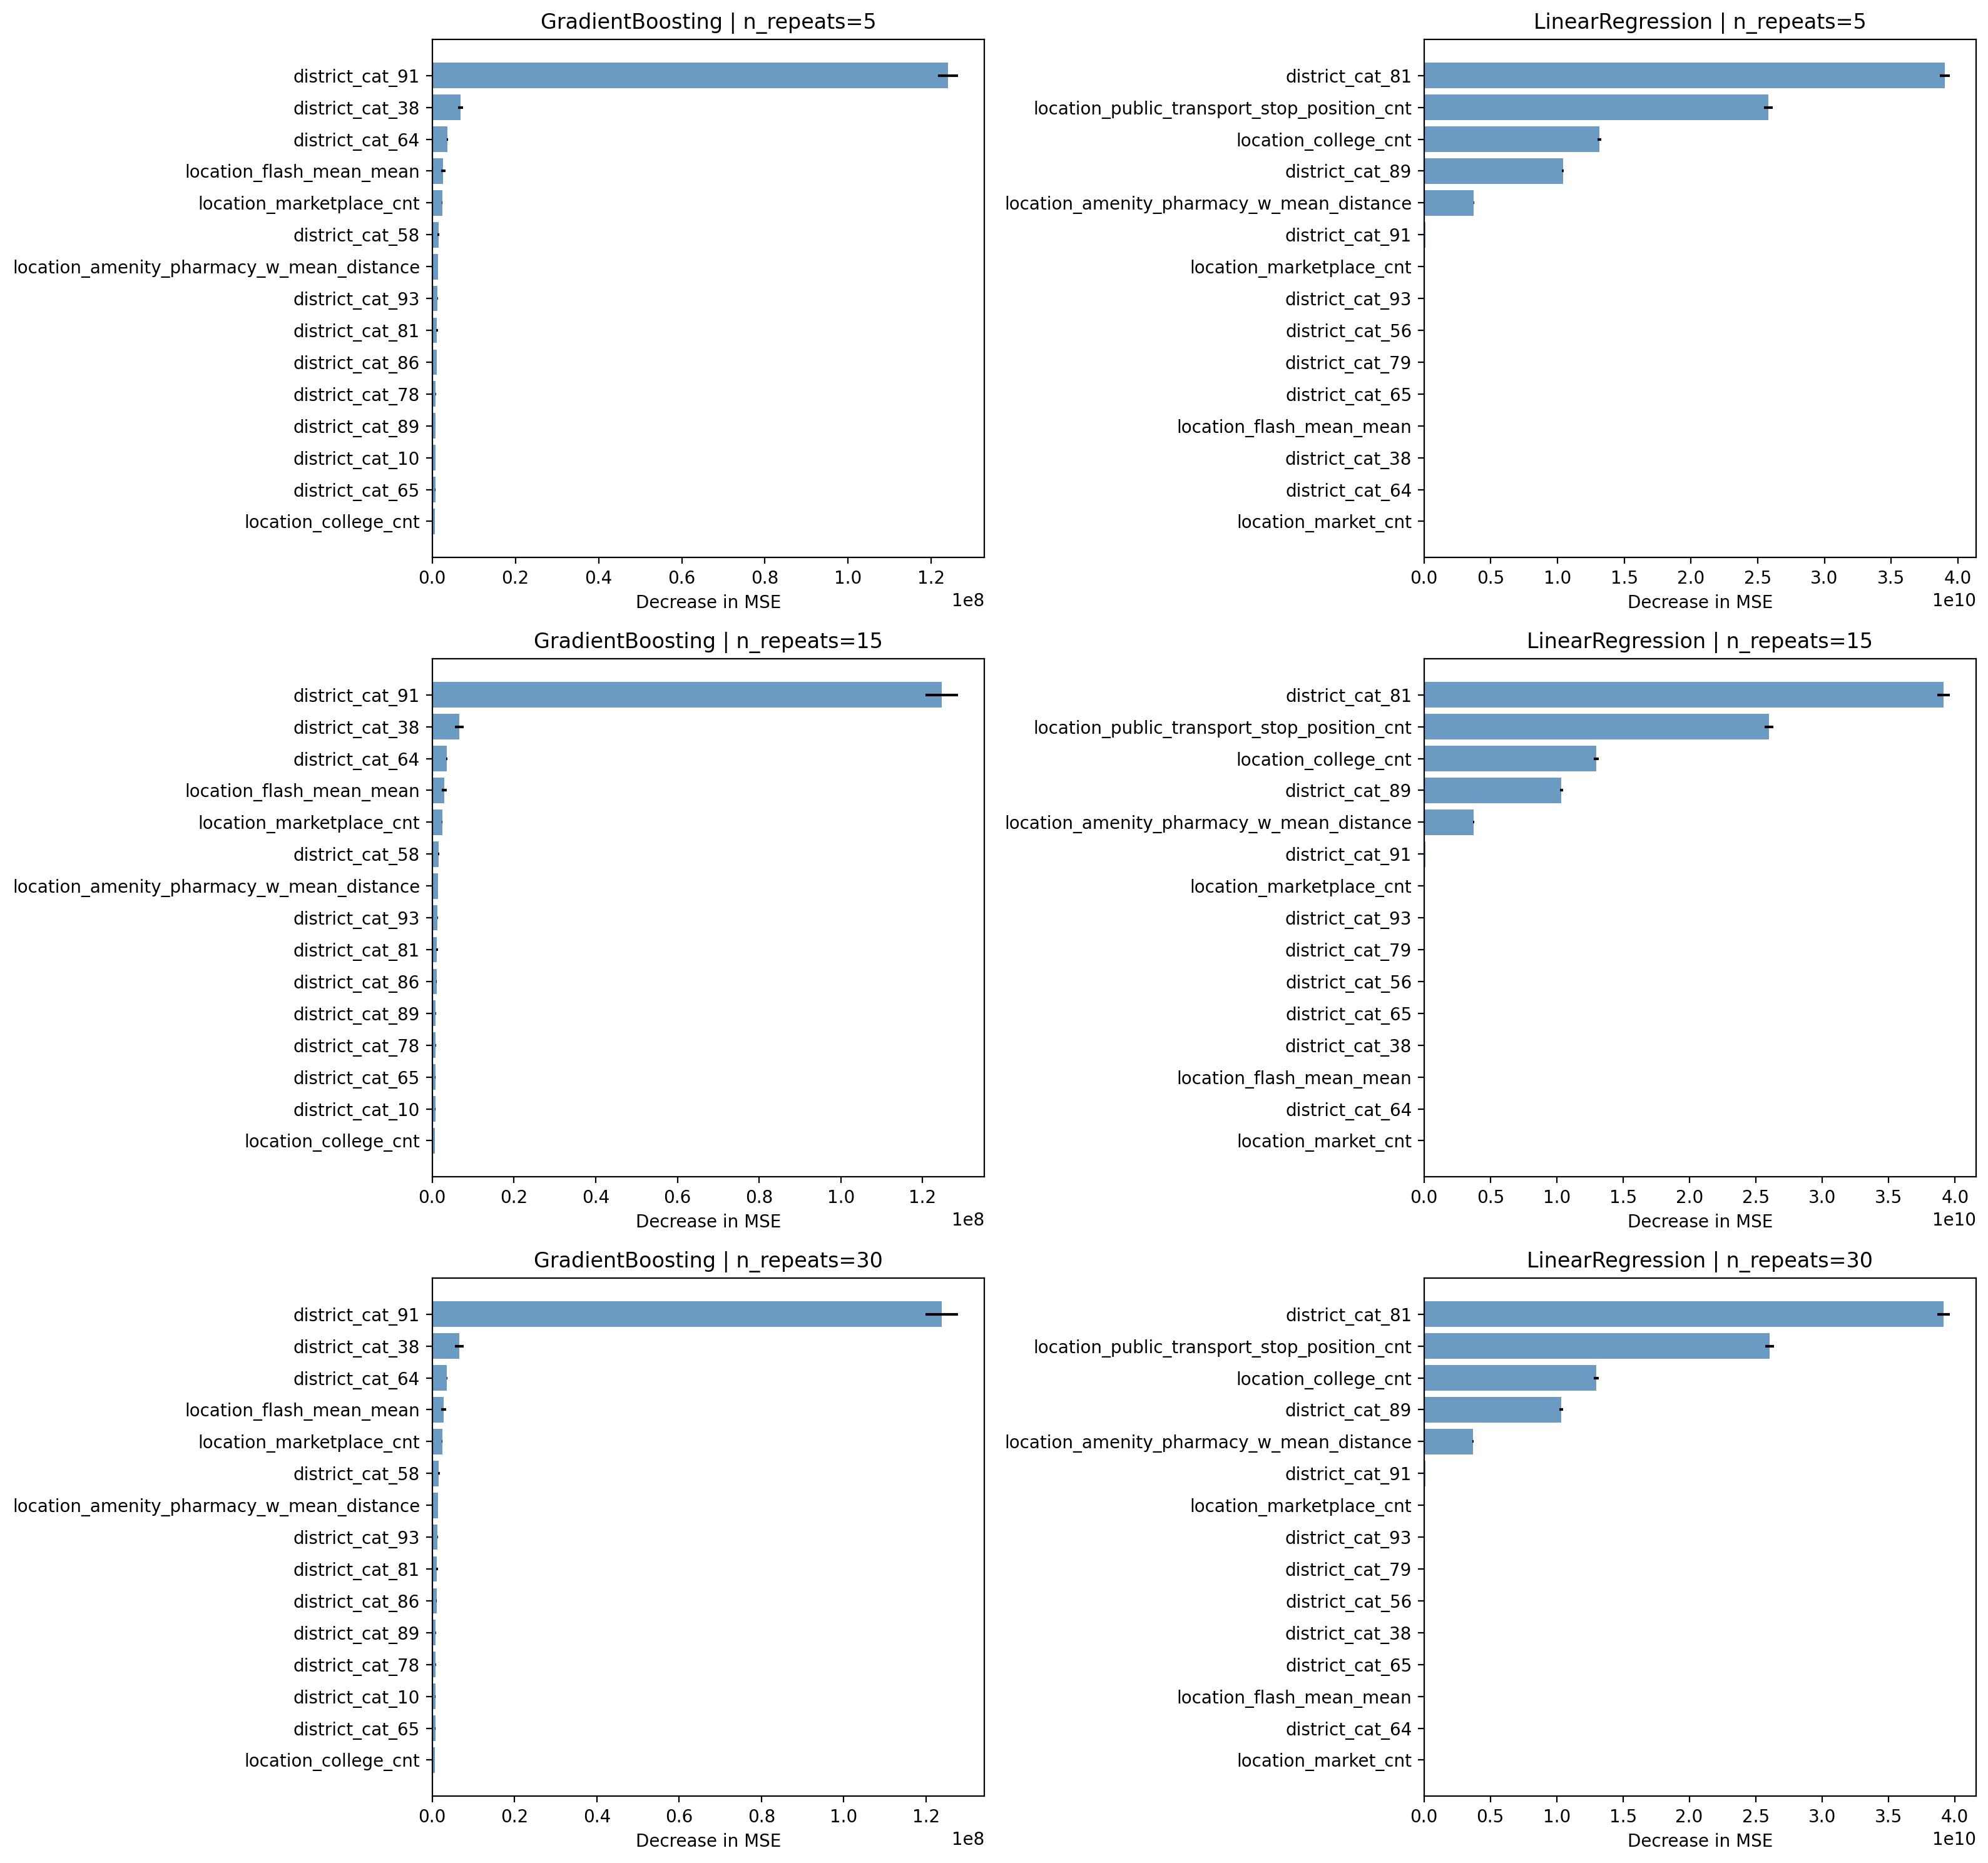

In [2]:
from sklearn.inspection import permutation_importance

n_repeats_list = [5, 15, 30]
ohe_names = (gb_model.named_steps["preprocessor"]
             .named_transformers_["cat"]["encoder"]
             .get_feature_names_out(cat_features))
features_all = list(num_features) + list(ohe_names) 

fig, axes = plt.subplots(len(n_repeats_list), 2,
                          figsize=(16, 5 * len(n_repeats_list)))

for row_i, n_rep in enumerate(n_repeats_list):
    for col_i, (model, name) in enumerate([(gb_model,  "GradientBoosting"),
                                            (lin_model, "LinearRegression")]):
        result = permutation_importance(
            model, X_test, y_test,
            n_repeats=n_rep, random_state=42,
            scoring="neg_mean_squared_error")
        sorted_idx = result.importances_mean.argsort()[::-1][:15]
        ax = axes[row_i, col_i]
        ax.barh([features_all[i] for i in sorted_idx],
                result.importances_mean[sorted_idx],
                xerr=result.importances_std[sorted_idx],
                color="steelblue", alpha=0.8)
        ax.invert_yaxis()
        ax.set_title(f"{name} | n_repeats={n_rep}")
        ax.set_xlabel("Decrease in MSE")

plt.tight_layout()
plt.show()


### Анализ

**Как меняются коэффициенты при росте n_repeats:**
Ранговый порядок признаков одинаков на всех трёх графиках: средние значения стабилизируются уже при n_repeats=5. Разница между графиками - в ширине планок погрешности. Визуально это незаметно из-за доминирования одного признака.

**Различия между моделями:**
- *GradientBoosting*: почти полностью доминирует `district_cat_91`, остальные признаки на порядок слабее.
- *LinearRegression*: важность распределена равномернее - лидируют `district_cat_81`, `location_public_transport_stop_position_cnt`, `location_college_cnt`.

**Вывод:**
В топе обеих моделей dummy-столбцы `district_cat`: цена сильно зависит от конкретного района. Среди числовых признаков значимы доступность транспорта и вузов, но только у линейной модели.
